In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Optional
from sklearn.preprocessing import OrdinalEncoder

def clean_dataset_to_categorical(
    in_path: str,
    out_path: str = "cleaned.csv",
    label_col: Optional[str] = None,
    discretize_numeric: bool = True,
    num_bins: int = 4,
    unknown_to_random: bool = True,
    encoding: str = "utf-8",
    random_seed: int = 42,
):
    """
    General-purpose cleaner:
    - Replaces "unknown", "NA", "" with random int in [0, 5]
    - Converts TRUE/FALSE to 1/0
    - Discretizes numeric columns (optional)
    - Encodes object columns to integers
    - Removes known leaky columns
    - Final dataset has only integers (0–5 or fewer)
    """
    np.random.seed(random_seed)
    rng = np.random.default_rng(random_seed)

    # 1) Load
    df = pd.read_csv(in_path, encoding=encoding)
    print(df.nunique())
    print(df.isna().sum())
    # 2) Replace common missing values with NaN
    df.replace(
        to_replace=["unknown", "Unknown", "NA", "na", "NaN", ""],
        value=np.nan,
        inplace=True,
    )

    # # 3) Convert string TRUE/FALSE to 1/0 (preserve NaNs)
    # for col in df.columns:
    #     s = df[col]
    #     # Only consider object-like or mixed types
    #     if s.dtype == "object" or pd.api.types.is_string_dtype(s):
    #         non_na_str = s.dropna().astype(str).str.lower()
    #         if not non_na_str.empty and non_na_str.isin({"true", "false"}).all():
    #             df[col] = (
    #                 s.astype(str).str.lower().map({"true": 1, "false": 0})
    #                 .astype("Int64")  # nullable int
    #             )
    # # 4) Strip quotes/spaces from string columns WITHOUT turning NaN into "nan"
    # for col in df.select_dtypes(include=["object"]).columns:
    #     df[col] = df[col].str.strip().str.strip('"').str.strip("'")

    # # 5) Discretize numeric features (excluding label)
    # if discretize_numeric:
    #     numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    #     if label_col and label_col in numeric_cols:
    #         numeric_cols.remove(label_col)
    #     for col in numeric_cols:
    #         try:
    #             # qcut can create NaNs for constant columns; handled later
    #             df[col] = pd.qcut(df[col], q=num_bins, labels=False, duplicates="drop")
    #         except Exception as e:
    #             print(f"[cleaner] Could not discretize {col}: {e}")

    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if cat_cols:
        try:
            enc = OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,  # sklearn >= 1.1
            )
            df[cat_cols] = enc.fit_transform(df[cat_cols]).astype("int64")
        except TypeError:
            # Fallback for older sklearn: encode unknown as -1, then convert NaN to -1
            enc = OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            )
            arr = enc.fit_transform(df[cat_cols])
            # Replace NaN from encoder with -1
            arr = np.where(np.isnan(arr), -1, arr)
            df[cat_cols] = arr.astype("int64")

    # 7) Impute NaN/-1 using values drawn from OBSERVED categories in each column
    #    (prevents introducing unseen categories, e.g., 2 in a binary column)
    for col in df.columns:
        s = df[col]
        # Work with numeric-like columns (after encoding/discretization most are numeric/Int64)
        mask = s.isna() | (s == -1)
        if mask.any():
            valid = s[~s.isna() & (s != -1)].unique()
            if valid.size > 0:
                df.loc[mask, col] = rng.choice(valid, size=int(mask.sum()))
            else:
                # If the whole column is missing, default to 0
                df.loc[mask, col] = 0

    # constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
    # if constant_cols:
    #     print(f"[cleaner] Dropping constant columns: {constant_cols}")
    #     df = df.drop(columns=constant_cols)

    # 8) Convert all columns to plain int (after imputation there should be no NaN/-1 carryover)
    df = df.astype(int)

    # # 9) Drop leaky columns
    # LEAKY_COLS = [
    #     "bar1", "bar2", "bar1_yr", "bar2_yr", "bar", "bar_passed",
    #     "Dropout", "dnn_bar_pass_prediction"
    # ]
    # df = df.drop(columns=[c for c in LEAKY_COLS if c in df.columns], errors="ignore")

    # 10) Save cleaned file
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    print(f"Cleaned dataset saved to: {out_path}")
    return out_path

# ---- Example usage for Legal Bar Pass dataset ----
clean_dataset_to_categorical(
    in_path="../data/Law/bar_pass_prediction.csv",
    out_path="../data/Law/bar_pass_clean_2.csv",
    label_col="pass_bar",
    num_bins=5
)

decile1b                      10
decile3                       10
ID                         22407
decile1                       10
sex                            2
race                           8
cluster                        6
lsat                         116
ugpa                          25
zfygpa                       563
DOB_yr                        51
grad                           3
zgpa                         588
bar1                           2
bar1_yr                        4
bar2                           2
bar2_yr                        4
fulltime                       2
fam_inc                        5
age                           57
gender                         2
parttime                       2
male                           2
race1                          5
race2                          3
Dropout                        2
other                          2
asian                          2
black                          2
hisp                           2
pass_bar  

'../data/Law/bar_pass_clean_2.csv'

In [47]:
import pandas as pd

df = pd.read_csv('../data/Law/bar_pass_clean_2.csv')
df.columns

Index(['decile1b', 'decile3', 'ID', 'decile1', 'race', 'cluster', 'lsat',
       'ugpa', 'zfygpa', 'DOB_yr', 'grad', 'zgpa', 'fam_inc', 'age', 'gender',
       'race1', 'race2', 'pass_bar', 'tier', 'index6040', 'indxgrp',
       'indxgrp2', 'gpa'],
      dtype='object')

In [51]:
df['tier'].value_counts()

tier
0    10303
1     6108
2     3922
3     2074
Name: count, dtype: int64

In [54]:
import pandas as pd

df = pd.read_csv('../data/Law/bar_pass_prediction.csv')
df['sex'].value_counts()

sex
2.0    12576
1.0     9826
Name: count, dtype: int64

In [43]:
df['other'].value_counts()

other
0    21999
1      408
Name: count, dtype: int64

In [ ]:
def check_column_mapping(df, col1, col2):
    mapping = df.groupby(col1)[col2].unique()

    valid = all(len(v) == 1 for v in mapping)
    return valid, {k: v[0] for k, v in mapping.items() if len(v) == 1}


import pandas as pd

df = pd.read_csv('../data/Law/bar_pass_prediction.csv')
print(df.columns)
valid, mapping = check_column_mapping(df, "sex", "gender")
print("Consistent mapping:", valid)
print("Mapping found:", mapping)


Index(['decile1b', 'decile3', 'ID', 'decile1', 'sex', 'race', 'cluster',
       'lsat', 'ugpa', 'zfygpa', 'DOB_yr', 'grad', 'zgpa', 'bar1', 'bar1_yr',
       'bar2', 'bar2_yr', 'fulltime', 'fam_inc', 'age', 'gender', 'parttime',
       'male', 'race1', 'race2', 'Dropout', 'other', 'asian', 'black', 'hisp',
       'pass_bar', 'bar', 'bar_passed', 'tier', 'index6040', 'indxgrp',
       'indxgrp2', 'dnn_bar_pass_prediction', 'gpa'],
      dtype='object')
Consistent mapping: True
Mapping found: {1.0: 'female', 2.0: 'male'}


In [3]:
df = pd.read_csv('../data/Law/bar_pass_1.csv')
print(df.columns)

Index(['decile1b', 'decile3', 'ID', 'decile1', 'sex', 'race', 'cluster',
       'lsat', 'ugpa', 'zfygpa', 'DOB_yr', 'grad', 'zgpa', 'fulltime',
       'fam_inc', 'age', 'gender', 'parttime', 'male', 'race1', 'race2',
       'other', 'asian', 'black', 'hisp', 'pass_bar', 'tier', 'index6040',
       'indxgrp', 'indxgrp2', 'gpa'],
      dtype='object')


In [ ]:
df['sex'].value_counts()

gender
1    12576
0     9826
2        5
Name: count, dtype: int64

In [6]:
df = pd.read_csv('../data/Law/bar_pass_1.csv')
print(df.columns)

Index(['decile1b', 'decile3', 'ID', 'decile1', 'sex', 'race', 'cluster',
       'lsat', 'ugpa', 'zfygpa', 'DOB_yr', 'grad', 'zgpa', 'fulltime',
       'fam_inc', 'age', 'gender', 'parttime', 'male', 'race1', 'race2',
       'other', 'asian', 'black', 'hisp', 'pass_bar', 'tier', 'index6040',
       'indxgrp', 'indxgrp2', 'gpa'],
      dtype='object')


In [7]:
df.nunique()

decile1b     6
decile3      6
ID           5
decile1      6
sex          4
race         5
cluster      6
lsat         5
ugpa         5
zfygpa       6
DOB_yr       6
grad         4
zgpa         6
fulltime     6
fam_inc      6
age          6
gender       3
parttime     6
male         5
race1        6
race2        4
other        1
asian        1
black        1
hisp         1
pass_bar     2
tier         6
index6040    5
indxgrp      7
indxgrp2     9
gpa          5
dtype: int64

In [20]:
df = pd.read_csv('../data/Law/bar_pass_prediction.csv')
print(df.columns)
df.nunique()

Index(['decile1b', 'decile3', 'ID', 'decile1', 'sex', 'race', 'cluster',
       'lsat', 'ugpa', 'zfygpa', 'DOB_yr', 'grad', 'zgpa', 'bar1', 'bar1_yr',
       'bar2', 'bar2_yr', 'fulltime', 'fam_inc', 'age', 'gender', 'parttime',
       'male', 'race1', 'race2', 'Dropout', 'other', 'asian', 'black', 'hisp',
       'pass_bar', 'bar', 'bar_passed', 'tier', 'index6040', 'indxgrp',
       'indxgrp2', 'dnn_bar_pass_prediction', 'gpa'],
      dtype='object')


decile1b                      10
decile3                       10
ID                         22407
decile1                       10
sex                            2
race                           8
cluster                        6
lsat                         116
ugpa                          25
zfygpa                       563
DOB_yr                        51
grad                           3
zgpa                         588
bar1                           2
bar1_yr                        4
bar2                           2
bar2_yr                        4
fulltime                       2
fam_inc                        5
age                           57
gender                         2
parttime                       2
male                           2
race1                          5
race2                          3
Dropout                        2
other                          2
asian                          2
black                          2
hisp                           2
pass_bar  

In [21]:
PROTECTED_ATTR = 'sex'
ADMISSIBLE_ATTRS = ["decile3", "decile1", "grad", "race"]
INADMISSIBLE_ATTRS = ["indxgrp2", "cluster", "tier"]

In [22]:
df[[PROTECTED_ATTR, 'pass_bar']+ADMISSIBLE_ATTRS+INADMISSIBLE_ATTRS].to_csv('../data/Law/test.csv', index=False)

In [24]:
# ---- Example usage for Legal Bar Pass dataset ----
clean_dataset_to_categorical(
    in_path="../data/Law/test.csv",
    out_path="../data/Law/bar_pass_clean_3.csv",
    label_col="pass_bar",
    num_bins=5
)

sex          2
pass_bar     2
decile3     10
decile1     10
grad         3
race         8
indxgrp2     9
cluster      6
tier         6
dtype: int64
sex            5
pass_bar       0
decile3     1604
decile1     1092
grad           3
race          16
indxgrp2       0
cluster       96
tier          96
dtype: int64
Cleaned dataset saved to: ../data/Law/bar_pass_clean_3.csv


'../data/Law/bar_pass_clean_3.csv'

In [25]:
df = pd.read_csv('../data/Law/bar_pass_clean_3.csv')
print(df.columns)
df.nunique()

Index(['sex', 'pass_bar', 'decile3', 'decile1', 'grad', 'race', 'indxgrp2',
       'cluster', 'tier'],
      dtype='object')


sex          2
pass_bar     2
decile3     10
decile1     10
grad         3
race         8
indxgrp2     9
cluster      6
tier         6
dtype: int64

In [28]:
df['race'].value_counts()

race
7    18719
3     1345
2      899
6      509
4      397
8      306
5      126
1      106
Name: count, dtype: int64

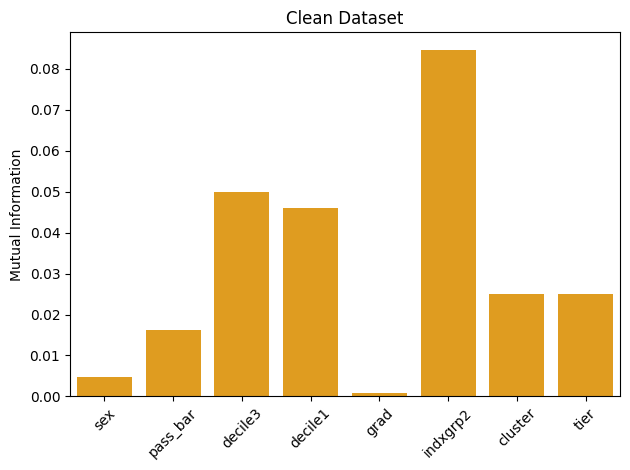

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Load datasets
f, CV = '0', '0'
clean_data = pd.read_csv(f'../data/Law/bar_pass_clean_3.csv')
datasets = {}
y_col = 'race'

# Compute mutual information
mi_results = {}
X = clean_data.drop(columns=[y_col])
y = clean_data[y_col]
mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_df = pd.DataFrame({'Attribute': X.columns, 'MI': mi_scores})
sorted_mi = mi_df.sort_values(by='MI', ascending=False)

sns.barplot(data=mi_df, x='Attribute', y='MI', color='orange')
plt.title(f'Clean Dataset')
plt.xlabel('')
plt.ylabel('Mutual Information')
plt.tick_params(axis='x', rotation=45)

# Hide unused subplot (bottom-left)
# axs[2][0].axis('off')

plt.tight_layout()
plt.show()


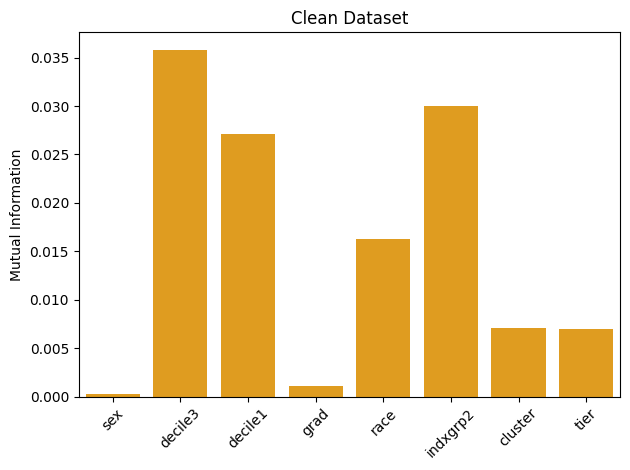

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Load datasets
f, CV = '0', '0'
clean_data = pd.read_csv(f'../data/Law/bar_pass_clean_3.csv')
datasets = {}
y_col = 'pass_bar'

# Compute mutual information
mi_results = {}
X = clean_data.drop(columns=[y_col])
y = clean_data[y_col]
mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_df = pd.DataFrame({'Attribute': X.columns, 'MI': mi_scores})
sorted_mi = mi_df.sort_values(by='MI', ascending=False)

sns.barplot(data=mi_df, x='Attribute', y='MI', color='orange')
plt.title(f'Clean Dataset')
plt.xlabel('')
plt.ylabel('Mutual Information')
plt.tick_params(axis='x', rotation=45)

# Hide unused subplot (bottom-left)
# axs[2][0].axis('off')

plt.tight_layout()
plt.show()
